In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import seaborn as sns

from pylab import rcParams
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [2]:
X, y = make_circles(n_samples=100, noise=0.1, random_state=1)
df = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'y': y})

<Axes: xlabel='x1', ylabel='x2'>

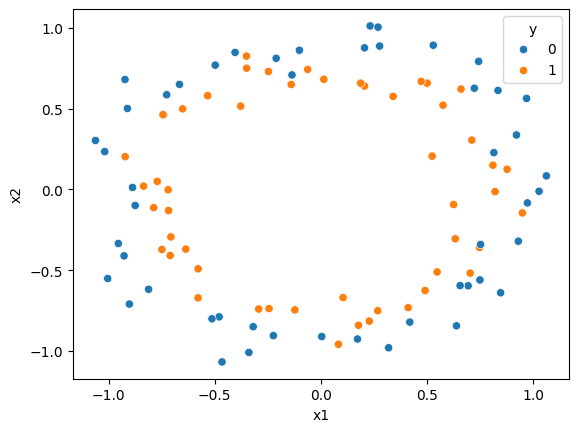

In [3]:
sns.scatterplot(data=df, x='x1', y='x2', hue='y')

In [4]:
X_train, X_test, y_train, y_test = train_test_split(df[['x1', 'x2']], df[['y']], test_size=0.20, random_state=2)

In [5]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3000, verbose=0)

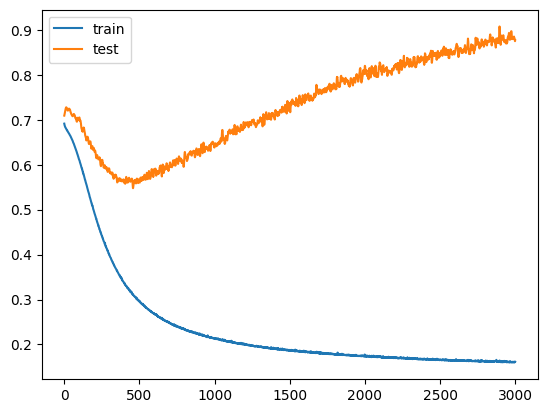

In [8]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step


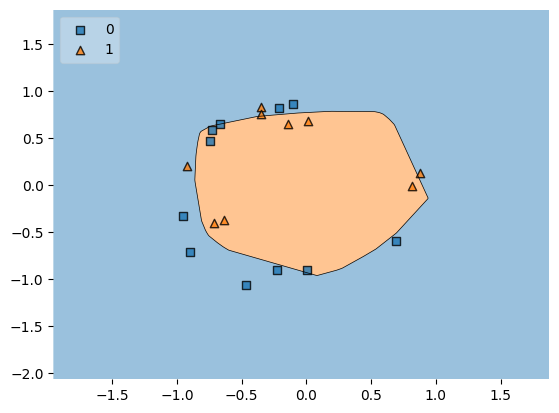

In [10]:
plot_decision_regions(np.array(X_test), np.array(y_test).reshape(-1,), clf=model, legend=2)
plt.show()

# Early Stopping

In [11]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [21]:
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [24]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [25]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3000, callbacks=callback)

Epoch 1/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6375 - loss: 0.6474 - val_accuracy: 0.4000 - val_loss: 0.7138
Epoch 2/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6500 - loss: 0.6465 - val_accuracy: 0.4000 - val_loss: 0.7126
Epoch 3/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6500 - loss: 0.6467 - val_accuracy: 0.4500 - val_loss: 0.7108
Epoch 4/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6500 - loss: 0.6449 - val_accuracy: 0.4500 - val_loss: 0.7103
Epoch 5/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6625 - loss: 0.6442 - val_accuracy: 0.4500 - val_loss: 0.7105
Epoch 6/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6750 - loss: 0.6435 - val_accuracy: 0.4000 - val_loss: 0.7111
Epoch 7/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7000 - loss: 0.6428 - val_accuracy: 0.4000 - val_loss: 0.7095
Epoch 8/3000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7000 - loss: 0.6417 - val_accuracy: 0.4500 - v

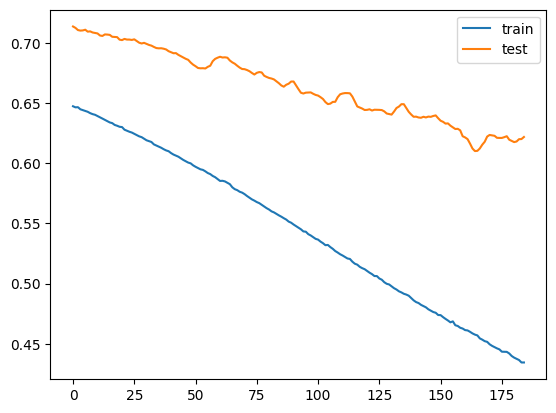

In [26]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


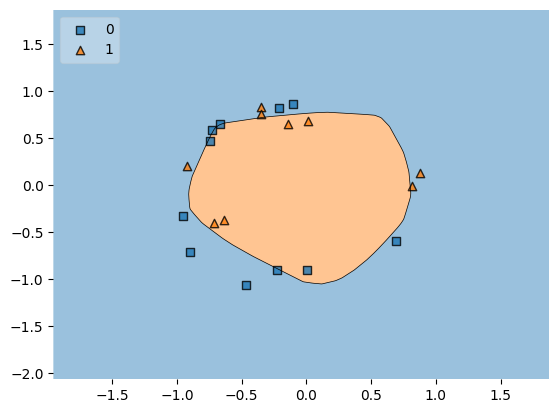

In [28]:
plot_decision_regions(X_test, y_test.reshape(-1, ), clf = model, legend=2)
plt.show()